In [ ]:
import pandas as pd
import geopandas as gpd
import xarray as xr
import rioxarray as rxr
import matplotlib.pyplot as plt
from rasterio.features import shapes
import rasterio
from shapely.geometry import shape
import contextily as cx
import numpy as np

In [2]:
basins_eu_me = gpd.read_file("../data/hybas_eu_lev01-06_v1c/hybas_eu_lev04_v1c.shp")
rivers_eu = gpd.read_file("../data/HydroRIVERS_v10_eu_shp/HydroRIVERS_v10_eu.shp")
countries = gpd.read_file("../data/world-administrative-boundaries/world-administrative-boundaries.shp")
mines = gpd.read_file("../data/mine_polygons/74548_projected polygons.shp")
flo_IPB = xr.open_dataset("../data/flo_IPB_last_date.nc")


In [3]:
mask_strahler_five = rivers_eu["ORD_STRA"] >= 5
rivers_eu_five = rivers_eu[mask_strahler_five]

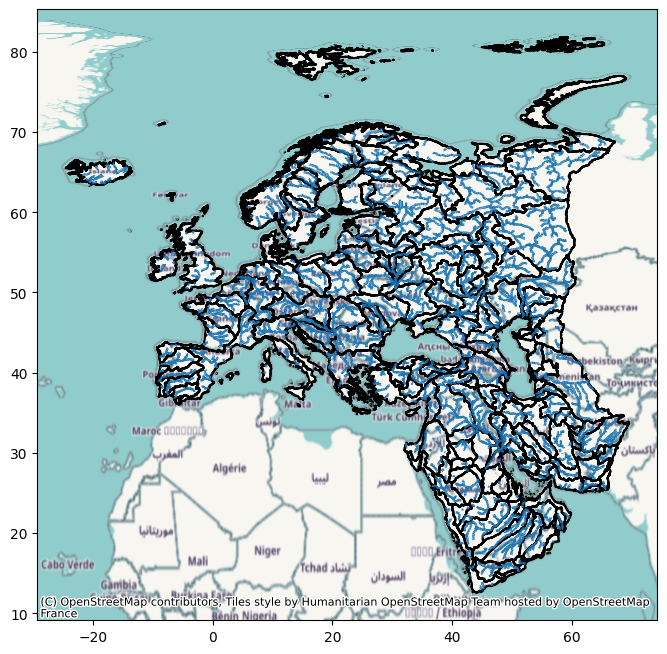

In [4]:
ax = basins_eu_me.boundary.plot(edgecolor = "k", figsize= (8, 8))
rivers_eu_five.plot(ax = ax)
cx.add_basemap(ax, crs=rivers_eu_five.crs);

In [5]:
IPB = basins_eu_me.iloc[45:53]
spain_mask  = countries["English_Nam"] == "Spain" 
portugal_mask = countries["English_Nam"] == "Portugal"
mask_iberia = spain_mask | portugal_mask
iberia = countries[mask_iberia]

In [6]:
rivers_in_IPB = gpd.sjoin(rivers_eu, IPB, predicate='intersects', how='inner')

In [7]:
print(flo_IPB["qav"].values.max())
print(flo_IPB["qav"].values.min())

nan
nan


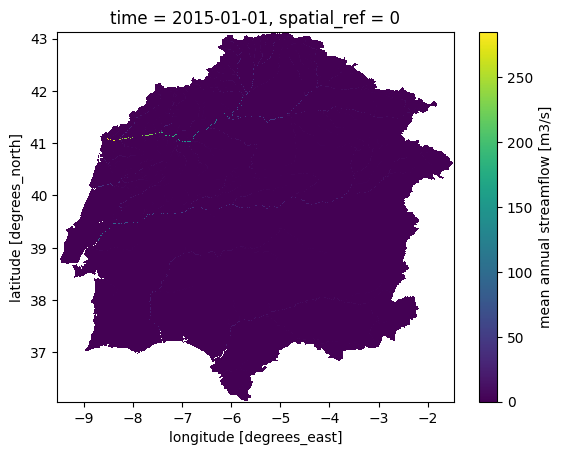

In [8]:
flo_IPB["qav"].plot()

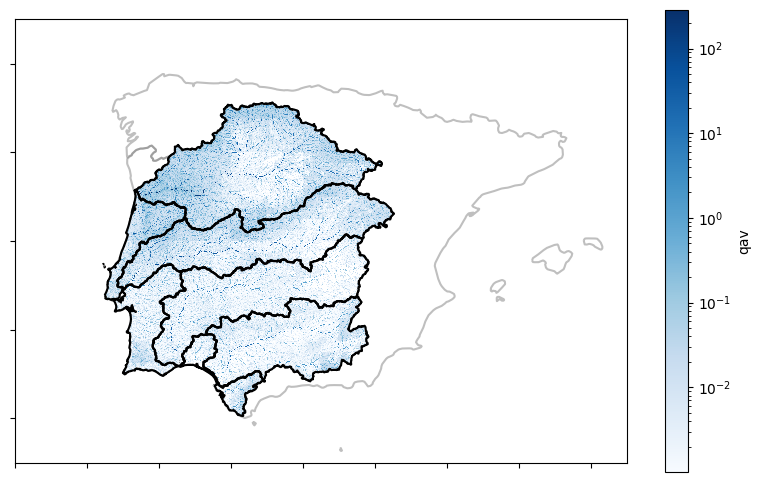

In [9]:
import matplotlib.colors as mcolors
fig, ax = plt.subplots(figsize = (8, 8))

IPB.boundary.plot(edgecolor = "k", zorder = 10, ax = ax)
iberia.boundary.plot(edgecolor = "grey", zorder = 1, ax = ax, alpha = 0.5)

flo_IPB_plot = flo_IPB["qav"].where(flo_IPB["qav"] > 0)
norm = mcolors.LogNorm(vmin=flo_IPB_plot.min(), vmax=flo_IPB_plot.max())
flo_IPB_plot.plot(ax = ax, cmap = "Blues",  norm = norm, cbar_kwargs={'shrink': 0.6, 'label': 'qav'})
ax.set_xlim(-12, 5)
ax.set_ylim(35, 45)
ax.set_xticklabels("")
ax.set_yticklabels("")
ax.set_ylabel("")
ax.set_xlabel("")
ax.set_title("")
plt.tight_layout()
fig.savefig("test_flo1k.png", dpi = 200)
plt.show()
plt.close()

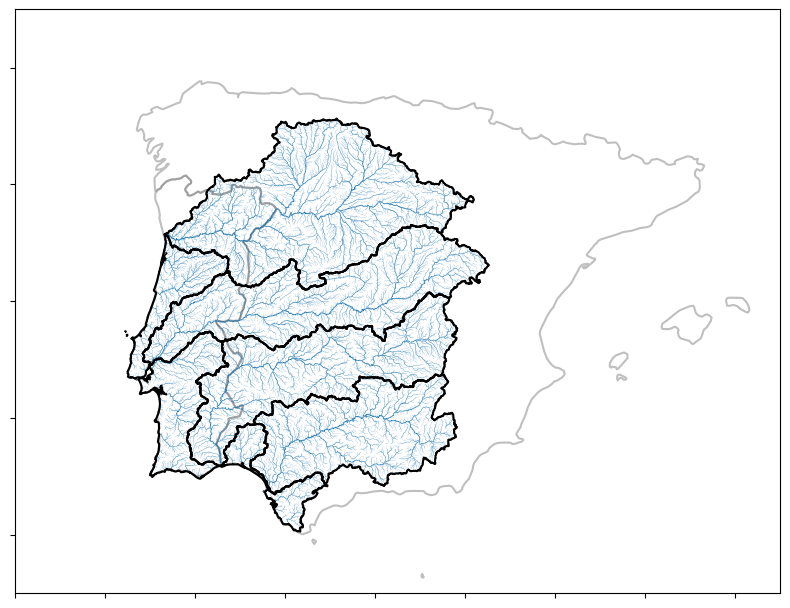

In [10]:
fig, ax = plt.subplots(figsize = (8, 8))
sizes = rivers_in_IPB["ORD_STRA"].fillna(1).astype(float) * 0.1
IPB.boundary.plot(edgecolor = "k", zorder = 10, ax = ax)
iberia.boundary.plot(edgecolor = "grey", zorder = 1, ax = ax, alpha = 0.5)
rivers_in_IPB.plot(ax = ax,linewidth=sizes)
ax.set_xlim(-12, 5)
ax.set_ylim(35, 45)
ax.set_xticklabels("")
ax.set_yticklabels("")
ax.set_ylabel("")
ax.set_xlabel("")
ax.set_title("")
plt.tight_layout()
fig.savefig("test_hydrorivers.png", dpi = 200)
plt.show()
plt.close()

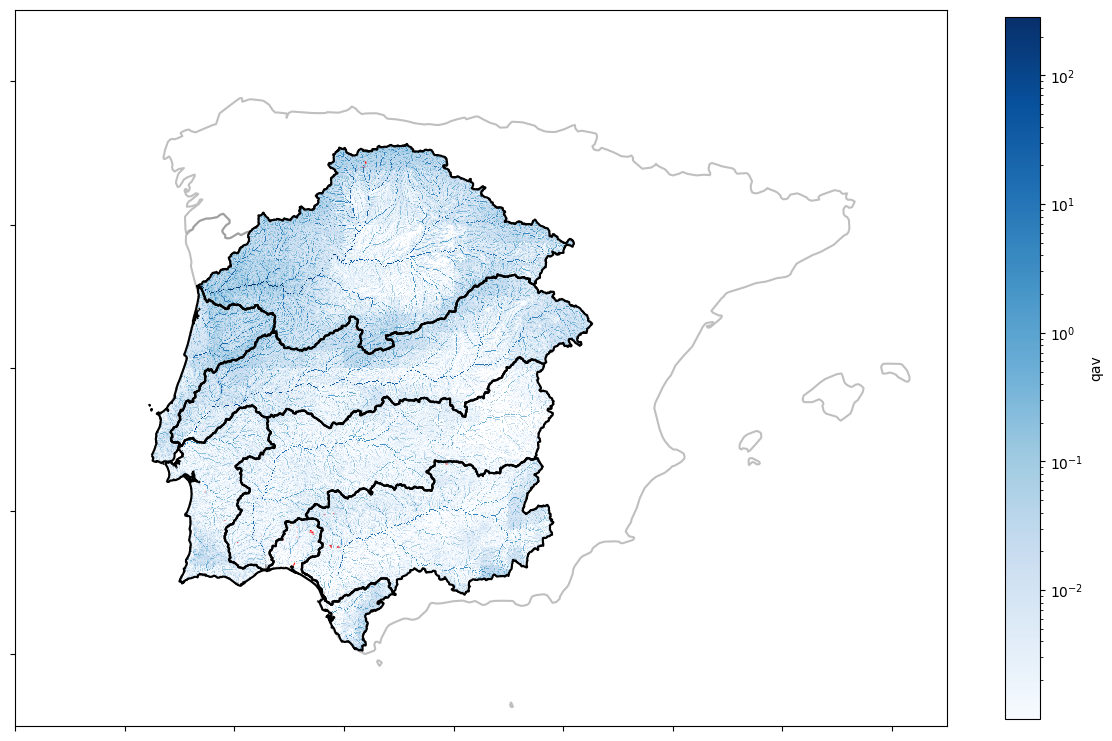

In [11]:
mines.to_crs(4326, inplace = True)
IPB_mines = gpd.sjoin(mines, IPB, predicate='intersects', how='inner')

fig, ax = plt.subplots(figsize = (12, 12))

IPB.boundary.plot(edgecolor = "k", zorder = 10, ax = ax)
iberia.boundary.plot(edgecolor = "grey", zorder = 1, ax = ax, alpha = 0.5)

flo_IPB_plot = flo_IPB["qav"].where(flo_IPB["qav"] > 0)
norm = mcolors.LogNorm(vmin=flo_IPB_plot.min(), vmax=flo_IPB_plot.max())
flo_IPB_plot.plot(ax = ax, cmap = "Blues",  norm = norm, cbar_kwargs={'shrink': 0.6, 'label': 'qav'})
IPB_mines.plot(ax = ax, color = "red")
ax.set_xlim(-12, 5)
ax.set_ylim(35, 45)
ax.set_xticklabels("")
ax.set_yticklabels("")
ax.set_ylabel("")
ax.set_xlabel("")
ax.set_title("")
plt.tight_layout()
fig.savefig("test_flo1k_mines.png", dpi = 200)
plt.show()
plt.close()


In [12]:
mines_raster = xr.open_dataset("../data/mines_raster_IPB.tif")
mines_raster

<xarray.Dataset> Size: 3MB
Dimensions:      (band: 1, x: 970, y: 848)
Coordinates:
  * band         (band) int64 8B 1
  * x            (x) float64 8kB -9.546 -9.538 -9.529 ... -1.487 -1.479 -1.471
  * y            (y) float64 7kB 36.06 36.07 36.08 36.09 ... 43.1 43.11 43.12
    spatial_ref  int64 8B ...
Data variables:
    band_data    (band, y, x) float32 3MB ...

In [13]:
mindat_po_df = pd.read_csv("../data/mindat_data/Portugal_pyrite.csv")
mindat_sp_df = pd.read_csv("../data/mindat_Data/Spain_pyrite.csv")
mindat_IPB_df = pd.concat([mindat_sp_df, mindat_po_df])
mindat_mineral_locations_IPB = gpd.points_from_xy(mindat_IPB_df["longitude"], mindat_IPB_df["latitude"], crs = "EPSG:4326")

In [14]:
mindat_mineral_locations_IPB = gpd.GeoDataFrame(mindat_mineral_locations_IPB)

In [15]:
IPB_mines.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

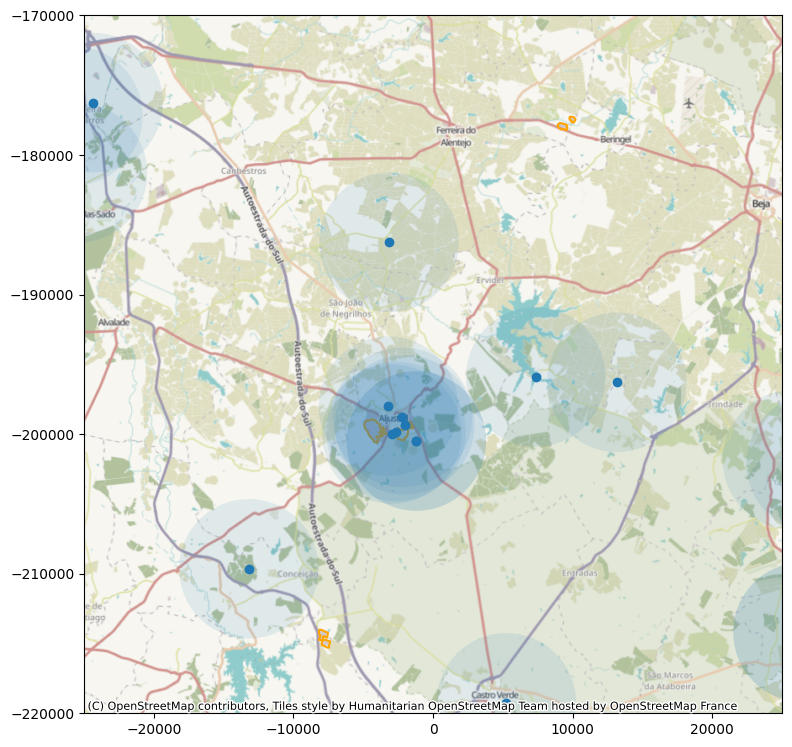

In [16]:
#37,8452°  -8,2005° : 37,9088°  -8,1342°
#https://www.mindat.org/a/aljustrel_mines
#https://www.mindat.org/loc-46429.ml
#https://www.mindat.org/loc-435303.html
#https://www.mindat.org/loc-204950.html

# setting crs to a EPSG:3763
IPB_mines = IPB_mines.to_crs(epsg = 3763)
mindat_mineral_locations_IPB = mindat_mineral_locations_IPB.set_geometry(col = 0).to_crs(epsg = 3763)
fig, ax = plt.subplots(figsize = (8, 8))

IPB_mines.boundary.plot(ax = ax, color = "orange", zorder= 1)
ax.set_xlim(-25000,  25000)
ax.set_ylim(-220000, -170000)
ax.set_ylabel("")
ax.set_xlabel("")
ax.set_title("")
# ax.set_xticklabels("")
# ax.set_yticklabels("")
plt.tight_layout()
cx.add_basemap(ax = ax, crs = IPB_mines.crs)
mindat_mineral_locations_IPB.plot(ax = ax);
mindat_mineral_locations_IPB.buffer(5000).plot(ax = ax, alpha=0.1);
IPB_mines = IPB_mines.to_crs(epsg = 4326)
mindat_mineral_locations_IPB = mindat_mineral_locations_IPB.to_crs(epsg = 4326)

In [17]:


raster = rxr.open_rasterio("../data/mines_raster_IPB.tif")

# the raster is in degrees, want to work in meters for accurate buffering
# reproject raster to a projected CRS (EPSG:3763 for Portugal)
raster_proj = raster.rio.reproject("EPSG:3763")

points = mindat_mineral_locations_IPB.set_geometry(col=0)
points = points.to_crs("EPSG:3763")

buffered = points.buffer(5000)



# clip raster using projected coordinates
filtered = raster_proj.rio.clip(buffered.geometry, buffered.crs, drop=True)
print(f"og shape = {raster.shape}, Filtered shape: {filtered.shape}")
print(f"Cells kept: {filtered.count().values} of og: {raster.count().values}")


og shape = (1, 848, 970), Filtered shape: (1, 987, 881)
Cells kept: 869547 of og: 822560


In [18]:
filtered

<xarray.DataArray (band: 1, y: 987, x: 881)> Size: 3MB
array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]],
      shape=(1, 987, 881), dtype=float32)
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 8kB 4.051e+05 4.043e+05 ... -3.961e+05 -3.969e+05
  * x            (x) float64 7kB -1.175e+05 -1.167e+05 ... 5.975e+05 5.983e+05
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0
    _FillValue:     0.0

In [19]:
raster = rxr.open_rasterio("../data/mines_raster_IPB.tif")

In [20]:

points = mindat_mineral_locations_IPB.set_geometry(col=0)
points_wgs84 = points.to_crs(raster.rio.crs)

In [21]:


# Create buffer in degrees (approximate 5km at Portugal latitude)
# 5km ≈ 0.045 degrees longitude, 0.045 degrees latitude at ~39°N
buffer_deg = 0.045
buffered_wgs84 = points_wgs84.buffer(buffer_deg)

# clip
filtered_wgs84 = raster.rio.clip(buffered_wgs84.geometry, buffered_wgs84.crs, drop=True)

print(f"Original: {raster.shape}")
print(f"Filtered (WGS84): {filtered_wgs84.shape}")


Original: (1, 848, 970)
Filtered (WGS84): (1, 848, 962)


C:\Users\luuc_\AppData\Local\Temp\ipykernel_28804\1671576093.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  buffered_wgs84 = points_wgs84.buffer(buffer_deg)


In [22]:
filtered_wgs84.to_netcdf("../data/filtered_mines_ipb.nc")

In [23]:
filtered_wgs84

<xarray.DataArray (band: 1, y: 848, x: 962)> Size: 3MB
array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]],
      shape=(1, 848, 962), dtype=float32)
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 7kB 36.06 36.07 36.08 36.09 ... 43.1 43.11 43.12
  * x            (x) float64 8kB -9.479 -9.471 -9.463 ... -1.487 -1.479 -1.471
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0
    _FillValue:     0.0

In [21]:
hydir_eu = rxr.open_rasterio("../data/hyd_eu_dir_30s.tif")

In [22]:
hydir_eu

<xarray.DataArray (band: 1, y: 8640, x: 11400)> Size: 98MB
[98496000 values with dtype=uint8]
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 69kB 84.0 83.99 83.98 83.97 ... 12.02 12.01 12.0
  * x            (x) float64 91kB -25.0 -24.99 -24.98 ... 69.98 69.99 70.0
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:             Area
    RepresentationType:        THEMATIC
    STATISTICS_APPROXIMATE:    YES
    STATISTICS_MAXIMUM:        128
    STATISTICS_MEAN:           29.904586262922
    STATISTICS_MINIMUM:        0
    STATISTICS_STDDEV:         37.908816488504
    STATISTICS_VALID_PERCENT:  32.59
    _FillValue:                255
    scale_factor:              1.0
    add_offset:                0.0
    long_name:                 Band_1

In [23]:
dir_ds = hydir_eu.to_dataset(name = "hydir")
dir_ds

<xarray.Dataset> Size: 99MB
Dimensions:      (band: 1, x: 11400, y: 8640)
Coordinates:
  * band         (band) int64 8B 1
  * x            (x) float64 91kB -25.0 -24.99 -24.98 ... 69.98 69.99 70.0
  * y            (y) float64 69kB 84.0 83.99 83.98 83.97 ... 12.02 12.01 12.0
    spatial_ref  int64 8B 0
Data variables:
    hydir        (band, y, x) uint8 98MB ...

In [ ]:
def hydir_IDs(ds):

    # extract band of 2d shape
    if 'band' in ds['hydir'].dims:
        hydir_2d = ds['hydir'].isel(band=0, drop=True)
    else:
        hydir_2d = ds['hydir']  # already 2D

    nrows, ncols = hydir_2d.shape
    N = nrows * ncols
    print(f"Grid size: {nrows} rows, {ncols} cols")

    # cell IDs as x * y 
    cell_ids = np.arange(nrows * ncols).reshape((nrows, ncols))

    # outflow ID init with -1 (no outflow)
    outflow_ids = np.full((nrows, ncols), -1, dtype=np.int64)

    # HydroSHEDS encoding: 1=E, 2=SE, 4=S, 8=SW, 16=W, 32=NW, 64=N, 128=NE
    encoding_to_offset = {
        1: (0, 1),    # E
        2: (1, 1),    # SE
        4: (1, 0),    # S
        8: (1, -1),   # SW
        16: (0, -1),  # W
        32: (-1, -1), # NW
        64: (-1, 0),  # N
        128: (-1, 1), # NE
        0: (0, 0),    # inland depression (flows to itself)
        # 255 is handled separately (NoData)
    }

    for code, (dy, dx) in encoding_to_offset.items():
        if code == 255:
            continue

        mask = hydir_2d == code
        if not mask.any():
            continue

        # row/column incides
        rows, cols = np.where(mask)   

        # target cell locs
        target_rows = rows + dy
        target_cols = cols + dx

        # check if targets are valid
        valid = (target_rows >= 0) & (target_rows < nrows) & \
                (target_cols >= 0) & (target_cols < ncols)

        valid_rows = rows[valid]
        valid_cols = cols[valid]
        valid_target_rows = target_rows[valid]
        valid_target_cols = target_cols[valid]

        # outflow ID == ID of target
        outflow_ids[valid_rows, valid_cols] = cell_ids[valid_target_rows, valid_target_cols]

    # save to dataset on coordinates
    spatial_dims = hydir_2d.dims   

    ds['ID'] = xr.DataArray(
        cell_ids,
        dims=spatial_dims,
        attrs={'description': 'Cell IDs', 'units': 'None'}
    )

    ds['outID'] = xr.DataArray(
        outflow_ids,
        dims=spatial_dims,
        attrs={'description': 'Outflow cell IDs', 'units': 'None'}
    )

    # mark IDs that are outflow targets
    targets = np.zeros(N, dtype= bool)
    out_flat = ds["outID"].values.ravel()
    valid_out = out_flat[out_flat != -1]
    targets[valid_out] = True

    # filter out 255 hydir cells
    valid_mask = (ds["hydir"].values != 255).ravel()
    valid_indices = np.where(valid_mask)[0]

    # filters and masks for no inflow cells (network sources)
    no_inflow_indices = valid_indices[~targets[valid_indices]]

    rows, cols = np.unravel_index(no_inflow_indices, (nrows, ncols))

    no_inflow_mask = np.zeros((nrows, ncols), dtype= bool)
    no_inflow_mask[rows, cols] = True

    # save to dataset
    ds["source"] = xr.DataArray(
        no_inflow_mask,
        dims = ds["ID"].dims,
        attrs = {"description": "Bolean of True: no inflow, False: has inflow", "units": "None"})
    return ds

In [25]:
dir_ds = hydir_IDs(dir_ds)
dir_ds

Grid size: 8640 rows, 11400 cols


array([[-1, -1, -1, ..., -1, -1, -1],
       [-1, -1, -1, ..., -1, -1, -1],
       [-1, -1, -1, ..., -1, -1, -1],
       ...,
       [-1, -1, -1, ..., -1, -1, -1],
       [-1, -1, -1, ..., -1, -1, -1],
       [-1, -1, -1, ..., -1, -1, -1]], shape=(8640, 11400))

<xarray.Dataset> Size: 2GB
Dimensions:      (band: 1, x: 11400, y: 8640)
Coordinates:
  * band         (band) int64 8B 1
  * x            (x) float64 91kB -25.0 -24.99 -24.98 ... 69.98 69.99 70.0
  * y            (y) float64 69kB 84.0 83.99 83.98 83.97 ... 12.02 12.01 12.0
    spatial_ref  int64 8B 0
Data variables:
    hydir        (band, y, x) uint8 98MB 255 255 255 255 255 ... 255 255 255 255
    ID           (y, x) int64 788MB 0 1 2 3 ... 98495997 98495998 98495999
    outID        (y, x) int64 788MB -1 -1 -1 -1 -1 -1 -1 ... -1 -1 -1 -1 -1 -1
    source       (y, x) bool 98MB False False False False ... False False False

In [ ]:
import sys


120